# `WavePacket` — Paquet d’ondes quantique

**Fichier source :** `src/quantum_sim/waves/wave_packet.py`

---

## 1. Contexte physique

Un **paquet d’ondes** est une superposition de plusieurs ondes planes. Contrairement à une onde plane pure (non localisée), cette superposition permet de représenter un état plus réaliste d’une particule localisée dans l’espace.

Dans cette implémentation discrète, on utilise :

$$
\psi(x,t) = \mathcal{N} \sum_{n=1}^{N} A_n \exp\left(i\big[k_n(x-x_{0,n}) - \omega_n t + \phi_n\big]\right)
$$

où :
- $A_n$ est l’amplitude complexe de la composante $n$
- $k_n$ son nombre d’onde
- $\omega_n$ sa pulsation
- $x_{0,n}$ son décalage spatial
- $\phi_n$ sa phase
- $\mathcal{N}$ est le facteur de normalisation.

---

## 2. Idée clé de l’implémentation

La classe `WavePacket` reçoit une liste de `PlaneWave`, puis **vectorise** leurs paramètres dans des tableaux NumPy. Cette stratégie évite les boucles Python lentes et permet un calcul matriciel rapide sur de grandes grilles spatiales.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_sim.waves.plane_wave import PlaneWave
from quantum_sim.waves.wave_packet import WavePacket
from quantum_sim.utils.constants import ELECTRON_MASS

np.set_printoptions(precision=3, suppress=True)

## 3. Construction d’un paquet d’ondes

On construit un paquet en prenant plusieurs nombres d’onde autour d’une valeur centrale $k_0$.

Les amplitudes suivent ici une enveloppe gaussienne en espace des impulsions (espace $k$), ce qui produit une localisation en espace réel.

In [13]:
# Paramètres du paquet
k0 = 8e9                  # nombre d'onde central (m^-1)
sigma_k = 8e8             # largeur en k
num_components = 41

k_values = np.linspace(k0 - 3*sigma_k, k0 + 3*sigma_k, num_components)

# Amplitudes gaussiennes (réelles pour simplifier la lecture)
weights = np.exp(-0.5 * ((k_values - k0) / sigma_k)**2)
weights = weights / np.max(weights)

plane_waves = [
    PlaneWave(
        amplitude=w,
        wave_number=k,
        position=0.0,
        phase=0.0,
        time=0.0,
        masse=ELECTRON_MASS,
    )
    for k, w in zip(k_values, weights)
]

wp = WavePacket(plane_waves=plane_waves)

print(f"Nombre de composantes : {len(wp.plane_waves)}")
print(f"Énergie moyenne <E>   : {wp.energy:.3e} J")
print(f"Énergie moyenne <E>   : {wp.energy / 1.602176634e-19:.3f} eV")

print("\nExtrait de la représentation impulsionnelle (k, A):")
for k, a in wp.momentum_components()[:5]:
    print(f"k={k:.3e} m^-1, A={a:.3f}")

Nombre de composantes : 41
Énergie moyenne <E>   : 3.926e-19 J
Énergie moyenne <E>   : 2.451 eV

Extrait de la représentation impulsionnelle (k, A):
k=5.600e+09 m^-1, A=0.011
k=5.720e+09 m^-1, A=0.017
k=5.840e+09 m^-1, A=0.026
k=5.960e+09 m^-1, A=0.039
k=6.080e+09 m^-1, A=0.056


## 4. Évaluation et normalisation

La méthode `normalize(start, end, points)` calcule

$$
\int_{x_{min}}^{x_{max}} |\psi(x)|^2 \, dx
$$

puis applique un facteur multiplicatif pour imposer une norme unitaire sur l’intervalle choisi.

In [14]:
x = np.linspace(-8e-9, 8e-9, 4000)

# Avant normalisation
psi_raw = wp.evaluate(x)
rho_raw = np.abs(psi_raw)**2
norm_raw = np.trapezoid(rho_raw, x)

# Normalisation sur l'intervalle
wp.normalize(start=x[0], end=x[-1], points=len(x))
psi_norm = wp.evaluate(x)
rho_norm = np.abs(psi_norm)**2
norm_norm = np.trapezoid(rho_norm, x)

print(f"Norme avant normalisation : {norm_raw:.6e}")
print(f"Norme après normalisation : {norm_norm:.6e}")

Norme avant normalisation : 6.186926e-07
Norme après normalisation : 1.000000e+00


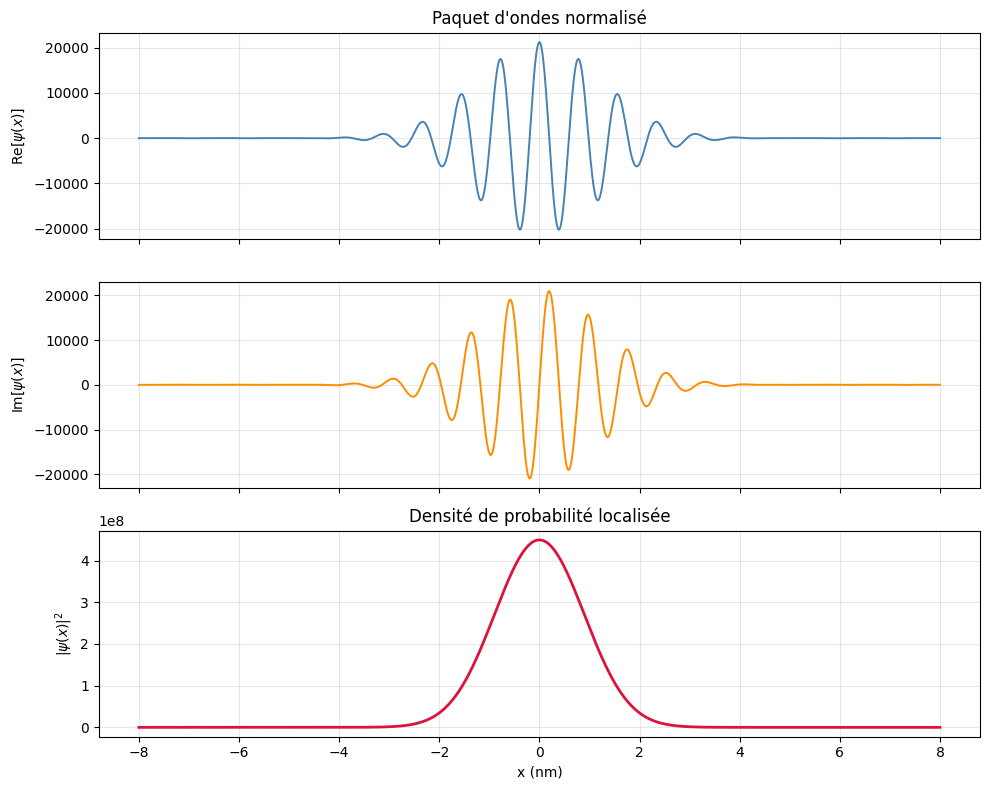

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(x*1e9, psi_norm.real, color='steelblue', lw=1.4)
axes[0].set_ylabel(r'Re$[\psi(x)]$')
axes[0].set_title("Paquet d'ondes normalisé")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x*1e9, psi_norm.imag, color='darkorange', lw=1.4)
axes[1].set_ylabel(r'Im$[\psi(x)]$')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x*1e9, rho_norm, color='crimson', lw=2)
axes[2].set_xlabel('x (nm)')
axes[2].set_ylabel(r'$|\psi(x)|^2$')
axes[2].set_title('Densité de probabilité localisée')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Propagation temporelle

Chaque composante évolue avec sa propre pulsation $\omega_n$, ce qui déforme globalement le paquet dans le temps (dispersion).

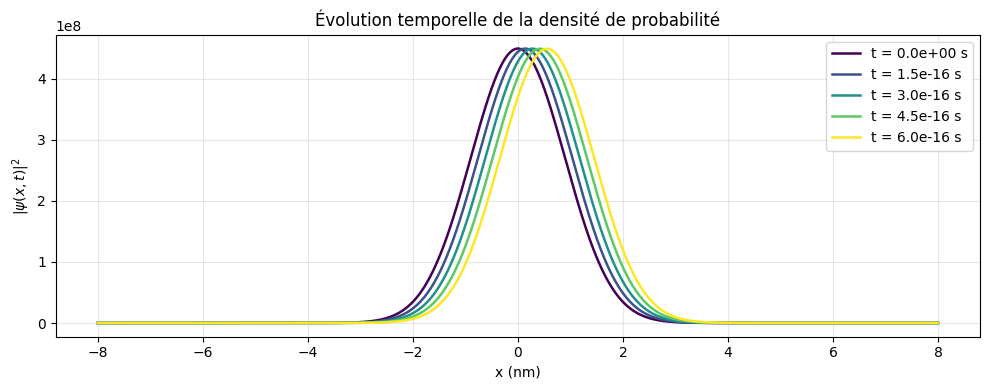

In [16]:
times = np.linspace(0, 6e-16, 5)
colors = plt.cm.viridis(np.linspace(0, 1, len(times)))

fig, ax = plt.subplots(figsize=(10, 4))
for t, c in zip(times, colors):
    psi_t = wp.evaluate(x, t=t)
    ax.plot(x*1e9, np.abs(psi_t)**2, color=c, lw=1.8, label=f't = {t:.1e} s')

ax.set_xlabel('x (nm)')
ax.set_ylabel(r'$|\psi(x,t)|^2$')
ax.set_title('Évolution temporelle de la densité de probabilité')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Résumé des méthodes `WavePacket`

| Méthode / propriété | Rôle |
|---|---|
| `evaluate(x, t=None)` | Calcule $\psi(x,t)$ via superposition vectorisée |
| `_evaluate_raw(x, t=None)` | Même calcul sans facteur de normalisation |
| `normalize(start, end, points)` | Ajuste $\mathcal{N}$ pour imposer une norme unité |
| `probability_density(x)` | Retourne $|\psi(x)|^2$ |
| `momentum_components()` | Donne la représentation discrète $(k_n, A_n)$ |
| `energy` / `energy_expectation()` | Calcule l’énergie moyenne pondérée par $|A_n|^2$ |

---

### Point important
Le calcul de l’énergie moyenne est
$$
\langle E \rangle = \sum_n w_n E_n, \quad w_n = \frac{|A_n|^2}{\sum_m |A_m|^2}
$$
ce qui correspond exactement à l’interprétation probabiliste des amplitudes quantiques.